<a href="https://colab.research.google.com/github/SaddamHosen42/Multi_class_and_Binary_heart_disease/blob/main/Multi_class_and_Binary_heart_disease_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Laibary**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
# ── Imbalanced-learn ─────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

# **STEP 1 – DATA LOADING**

In [11]:
# Cleveland Heart Disease dataset (UCI processed version)
# 303 samples × 14 columns; '?' denotes missing values
url = ('https://raw.githubusercontent.com/SaddamHosen42/'
       'Heart-Disease-Prediction/refs/heads/main/processed.cleveland.data')

col_names = ['age','sex','cp','trestbps','chol','fbs',
             'restecg','thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, header=None, names=col_names, na_values='?')
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (303, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


# **STEP 2 – PREPROCESSING**

In [12]:
# 2-a: Fill missing values with column mode (most frequent value)
#      Only 'ca' and 'thal' have missing entries in this dataset
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# 2-b: Label Encoding – convert categorical columns to integers
#      Required so all classifiers receive numeric input (paper §3.1.1)
le = LabelEncoder()
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 2-c: Separate feature matrix from target vector
X = df.drop('target', axis=1).values          # shape: (303, 13)

# Binary target  – 0 = no disease, 1 = disease (original classes 1-4 → 1)
y_binary = (df['target'] > 0).astype(int).values

# Multi-class target – 0 = no disease, 1/2/3/4 = increasing severity
y_multi  = df['target'].values

print("\nBinary class distribution :")
unique, counts = np.unique(y_binary, return_counts=True)
print(dict(zip(unique, counts)))

print("\nMulti-class distribution   :")
unique, counts = np.unique(y_multi, return_counts=True)
print(dict(zip(unique, counts)))


Binary class distribution :
{np.int64(0): np.int64(164), np.int64(1): np.int64(139)}

Multi-class distribution   :
{np.int64(0): np.int64(164), np.int64(1): np.int64(55), np.int64(2): np.int64(36), np.int64(3): np.int64(35), np.int64(4): np.int64(13)}


# **STEP 2.1 – FEATURE SELECTION**

## Correlation (Linear – Continuous Features)

  FEATURE SELECTION – STEP 2.5

[1] Pearson Correlation with Binary Target:
----------------------------------------
  age         : r = +0.2231  (Positive)
  trestbps    : r = +0.1508  (Positive)
  chol        : r = +0.0852  (Positive)
  thalach     : r = -0.4172  (Negative)
  oldpeak     : r = +0.4245  (Positive)


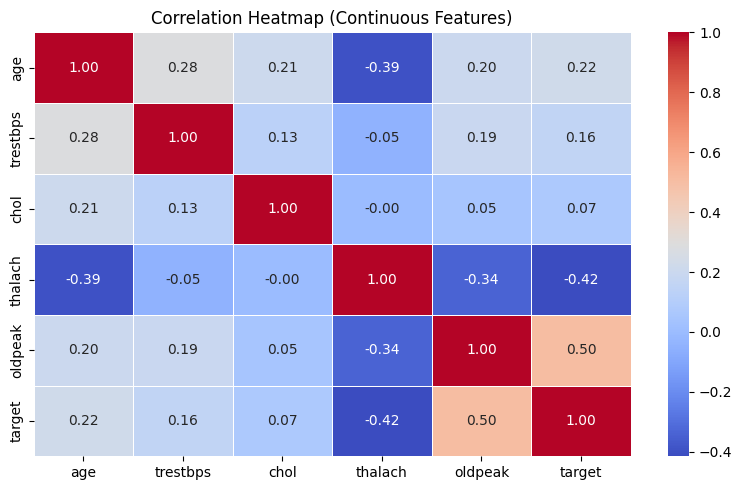

In [13]:
# ── Correlation Analysis (Continuous features vs Binary target) ──────────
import seaborn as sns

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print("=" * 55)
print("  FEATURE SELECTION – STEP 2.5")
print("=" * 55)

# Pearson Correlation with binary target
corr_vals = df[continuous_cols].corrwith(pd.Series(y_binary, name='target'))
print("\n[1] Pearson Correlation with Binary Target:")
print("-" * 40)
for feat, val in corr_vals.items():
    direction = "Positive" if val > 0 else "Negative"
    print(f"  {feat:<12}: r = {val:+.4f}  ({direction})")

# Heatmap
plt.figure(figsize=(8, 5))
corr_matrix = df[continuous_cols + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Continuous Features)")
plt.tight_layout()
plt.show()

## Mutual Information (Non-linear)


[2] Mutual Information Scores (All Features vs Binary Target):
--------------------------------------------------
  thal        : MI = 0.1482  █████
  ca          : MI = 0.1341  █████
  cp          : MI = 0.1330  █████
  oldpeak     : MI = 0.1247  ████
  exang       : MI = 0.0964  ███
  slope       : MI = 0.0873  ███
  chol        : MI = 0.0794  ███
  thalach     : MI = 0.0548  ██
  fbs         : MI = 0.0382  █
  sex         : MI = 0.0235  
  age         : MI = 0.0080  
  restecg     : MI = 0.0002  
  trestbps    : MI = 0.0000  


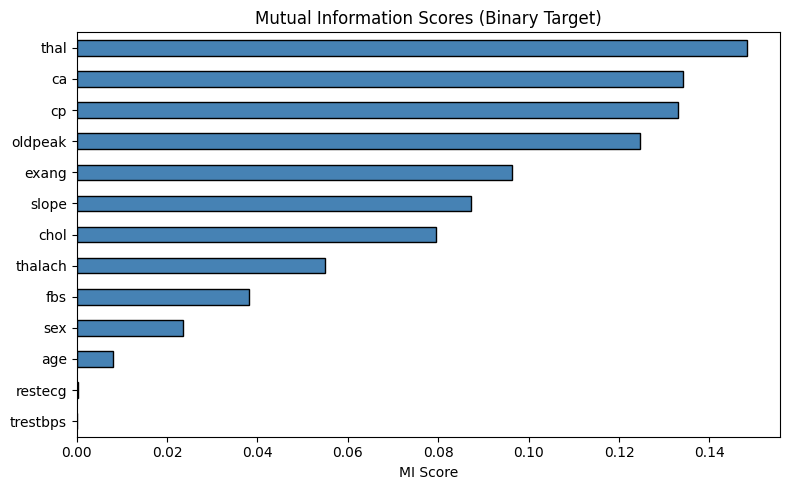

In [14]:
# ── Mutual Information (Non-linear relationship) ─────────────────────────
from sklearn.feature_selection import mutual_info_classif

print("\n[2] Mutual Information Scores (All Features vs Binary Target):")
print("-" * 50)

mi_scores = mutual_info_classif(X, y_binary, random_state=42)
mi_series = pd.Series(mi_scores,
                      index=df.drop('target', axis=1).columns)
mi_series = mi_series.sort_values(ascending=False)

for feat, score in mi_series.items():
    bar = "█" * int(score * 40)
    print(f"  {feat:<12}: MI = {score:.4f}  {bar}")

# Plot
plt.figure(figsize=(8, 5))
mi_series.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Mutual Information Scores (Binary Target)")
plt.xlabel("MI Score")
plt.tight_layout()
plt.show()

## Chi-Square Test (Categorical features)

In [15]:
# ── Chi-Square Test (Categorical Features vs Binary Target) ──────────────
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler as MMS

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
X_cat = df[categorical_cols].values

# chi2 requires non-negative values → MinMaxScale
X_cat_scaled = MMS().fit_transform(X_cat)
chi2_scores, p_values = chi2(X_cat_scaled, y_binary)

print("\n[3] Chi-Square Test (Categorical Features vs Binary Target):")
print("-" * 60)
print(f"  {'Feature':<12}  {'χ² Score':>10}  {'p-value':>12}  {'Important?'}")
print(f"  {'-'*12}  {'-'*10}  {'-'*12}  {'-'*10}")
for feat, chi, pv in zip(categorical_cols, chi2_scores, p_values):
    important = "✓ YES (p ≤ 0.05)" if pv <= 0.05 else "✗ NO  (p > 0.05)"
    print(f"  {feat:<12}  {chi:>10.4f}  {pv:>12.6f}  {important}")


[3] Chi-Square Test (Categorical Features vs Binary Target):
------------------------------------------------------------
  Feature         χ² Score       p-value  Important?
  ------------  ----------  ------------  ----------
  sex               7.4328      0.006404  ✓ YES (p ≤ 0.05)
  cp                7.3849      0.006577  ✓ YES (p ≤ 0.05)
  fbs               0.1647      0.684894  ✗ NO  (p > 0.05)
  restecg           4.3224      0.037613  ✓ YES (p ≤ 0.05)
  exang            38.0526      0.000000  ✓ YES (p ≤ 0.05)
  slope            10.9843      0.000919  ✓ YES (p ≤ 0.05)
  ca               28.0384      0.000000  ✓ YES (p ≤ 0.05)
  thal             44.2278      0.000000  ✓ YES (p ≤ 0.05)


## p-value (Statistical Significance – all features)

In [16]:
# ── p-value via f_classif (ANOVA F-test for all features) ────────────────
from sklearn.feature_selection import f_classif

f_scores, p_vals = f_classif(X, y_binary)
feature_names = df.drop('target', axis=1).columns

print("\n[4] Statistical Significance (ANOVA F-test, p-value):")
print("-" * 60)
print(f"  {'Feature':<12}  {'F-Score':>10}  {'p-value':>12}  {'Important?'}")
print(f"  {'-'*12}  {'-'*10}  {'-'*12}  {'-'*10}")

important_features = []
for feat, f, pv in zip(feature_names, f_scores, p_vals):
    important = "✓ YES (p ≤ 0.05)" if pv <= 0.05 else "✗ NO  (p > 0.05)"
    if pv <= 0.05:
        important_features.append(feat)
    print(f"  {feat:<12}  {f:>10.4f}  {pv:>12.6f}  {important}")

print(f"\n  → Statistically important features: {important_features}")


[4] Statistical Significance (ANOVA F-test, p-value):
------------------------------------------------------------
  Feature          F-Score       p-value  Important?
  ------------  ----------  ------------  ----------
  age              15.7696      0.000090  ✓ YES (p ≤ 0.05)
  sex              24.9789      0.000001  ✓ YES (p ≤ 0.05)
  cp               62.4238      0.000000  ✓ YES (p ≤ 0.05)
  trestbps          7.0066      0.008548  ✓ YES (p ≤ 0.05)
  chol              2.1991      0.139142  ✗ NO  (p > 0.05)
  fbs               0.1922      0.661376  ✗ NO  (p > 0.05)
  restecg           8.8714      0.003132  ✓ YES (p ≤ 0.05)
  thalach          63.4192      0.000000  ✓ YES (p ≤ 0.05)
  exang            69.0209      0.000000  ✓ YES (p ≤ 0.05)
  oldpeak          66.1667      0.000000  ✓ YES (p ≤ 0.05)
  slope            39.1382      0.000000  ✓ YES (p ≤ 0.05)
  ca               80.8006      0.000000  ✓ YES (p ≤ 0.05)
  thal            109.1636      0.000000  ✓ YES (p ≤ 0.05)

  → Statis

## AUC per feature + Final selected features

In [17]:
# ── AUC per Feature (Individual classification power) ────────────────────
from sklearn.linear_model import LogisticRegression as LR_
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler as SS_

print("\n[5] AUC Score per Feature (Binary Target):")
print("-" * 50)
print(f"  {'Feature':<12}  {'AUC':>8}  {'Quality'}")
print(f"  {'-'*12}  {'-'*8}  {'-'*20}")

auc_scores = {}
for i, feat in enumerate(feature_names):
    Xi = X[:, i].reshape(-1, 1)
    Xi_sc = SS_().fit_transform(Xi)
    score = cross_val_score(LR_(max_iter=1000, random_state=42),
                            Xi_sc, y_binary,
                            cv=5, scoring='roc_auc').mean()
    auc_scores[feat] = score
    quality = "Excellent" if score >= 0.75 else ("Good" if score >= 0.65 else "Weak")
    print(f"  {feat:<12}  {score:>8.4f}  {quality}")

# ── Final Feature Selection Summary ──────────────────────────────────────
print("\n" + "=" * 55)
print("  FEATURE SELECTION SUMMARY")
print("=" * 55)

# Combined score: MI rank + p-value significance + AUC
mi_rank    = mi_series.rank(ascending=False)
auc_series = pd.Series(auc_scores)

selected_features = []
print(f"\n  {'Feature':<12}  {'MI Score':>9}  {'AUC':>8}  {'p≤0.05?':>8}  {'Selected?'}")
print(f"  {'-'*12}  {'-'*9}  {'-'*8}  {'-'*8}  {'-'*10}")

for feat in feature_names:
    mi  = mi_series.get(feat, 0)
    auc = auc_series.get(feat, 0)
    pv  = p_vals[list(feature_names).index(feat)]
    sig = pv <= 0.05

    # Select if: MI > 0.05 OR AUC > 0.60 OR p ≤ 0.05
    select = (mi > 0.05) or (auc > 0.60) or sig
    if select:
        selected_features.append(feat)
    mark = "✓ YES" if select else "✗ NO"
    print(f"  {feat:<12}  {mi:>9.4f}  {auc:>8.4f}  {'Yes' if sig else 'No':>8}  {mark}")

print(f"\n  → Final selected features ({len(selected_features)}): {selected_features}")

# ── Update X with selected features only ─────────────────────────────────
X = df[selected_features].values
print(f"\n  → X updated: shape = {X.shape}")
print("  → Proceeding with selected features for model training.\n")


[5] AUC Score per Feature (Binary Target):
--------------------------------------------------
  Feature            AUC  Quality
  ------------  --------  --------------------
  age             0.6349  Weak
  sex             0.6296  Weak
  cp              0.7541  Excellent
  trestbps        0.5721  Weak
  chol            0.5708  Weak
  fbs             0.4542  Weak
  restecg         0.5865  Weak
  thalach         0.7406  Good
  exang           0.7038  Good
  oldpeak         0.7363  Good
  slope           0.6889  Good
  ca              0.7516  Excellent
  thal            0.7642  Excellent

  FEATURE SELECTION SUMMARY

  Feature        MI Score       AUC   p≤0.05?  Selected?
  ------------  ---------  --------  --------  ----------
  age              0.0080    0.6349       Yes  ✓ YES
  sex              0.0235    0.6296       Yes  ✓ YES
  cp               0.1330    0.7541       Yes  ✓ YES
  trestbps         0.0000    0.5721       Yes  ✓ YES
  chol             0.0794    0.5708        No  ✓ 

# **STEP 3 – HELPER FUNCTIONS**

In [35]:
def scale_fold(X_train_fold, X_val_fold, method='standard'):
    """
    Fit scaler ONLY on the training fold, then transform both folds.
    This is the correct way to prevent data leakage:
    the validation fold must NEVER influence the scaler's parameters.

    method='standard' → StandardScaler (z-score): used for LR / SVM / ANN
    method='minmax'   → MinMaxScaler  (0-1 range): used for DT / RF / ADA
    """
    scaler = StandardScaler() if method == 'standard' else MinMaxScaler()
    X_tr_sc  = scaler.fit_transform(X_train_fold)   # fit + transform
    X_val_sc = scaler.transform(X_val_fold)          # transform only
    return X_tr_sc, X_val_sc


def evaluate_fold(y_true, y_pred, y_prob=None, multi=False):
    """
    Compute five classification metrics for one CV fold:
      Accuracy  – fraction of correct predictions
      Precision – weighted/macro average across classes
      Recall    – sensitivity (true positive rate)
      F1-Score  – harmonic mean of precision & recall
      ROC-AUC   – area under ROC curve (None if not computable)

    multi=True  → weighted average (handles 5-class imbalance)
    multi=False → macro average (equal weight per class for binary)
    """
    avg = 'weighted' if multi else 'macro'
    acc = accuracy_score(y_true, y_pred) * 100
    prc = precision_score(y_true, y_pred, average=avg, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average=avg, zero_division=0) * 100
    f1  = f1_score(y_true, y_pred, average=avg, zero_division=0) * 100
    roc = None
    if y_prob is not None:
        try:
            if multi:
                # One-vs-Rest AUC for multi-class
                roc = roc_auc_score(y_true, y_prob,
                                    multi_class='ovr',
                                    average='macro') * 100
            else:
                # Probability of positive class (column 1)
                roc = roc_auc_score(y_true, y_prob[:, 1]) * 100
        except Exception:
            roc = None    # e.g. a class absent in this fold's val set
    return acc, prc, rec, f1, roc


def print_fold_result(fold_idx, label, acc, prc, rec, f1, roc=None):
    """Print metrics for one fold in a compact, aligned format."""
    roc_str = f"  ROC-AUC={roc:.2f}%" if roc is not None else ""
    print(f"    Fold {fold_idx} [{label:<18}] "
          f"Acc={acc:.2f}%  Prec={prc:.2f}%  "
          f"Recall={rec:.2f}%  F1={f1:.2f}%{roc_str}")


def print_cv_summary(label, scores_dict):
    """
    Print mean ± std for every metric after all 5 folds complete.
    scores_dict keys: 'acc', 'prc', 'rec', 'f1', 'roc'
    """
    print(f"\n  ── CV Summary [{label}] ──────────────────────────────")
    for metric, vals in scores_dict.items():
        arr = [v for v in vals if v is not None]  # skip None ROC entries
        if arr:
            print(f"    {metric.upper():<8}: "
                  f"{np.mean(arr):.2f}% ± {np.std(arr):.2f}%")


def weighted_score_fusion(model1, model2, X_val, y_val,
                           w_range=None, multi=False):
    """
    Weighted Score Fusion – paper §3.1.3 & Algorithm 1.

    Equation (3):  fused_prob = W1 * prob1 + W2 * prob2
                   where W1 + W2 = 1

    Sweeps W1 from 0.95 down to 0.05 in steps of 0.05.
    Picks the weight pair that maximises accuracy on the validation fold.
    Returns: (best_predictions, best_fused_probs, best_W1)

    IMPORTANT: Both models MUST have been trained on the SAME
    training fold and evaluated on the SAME validation fold.
    """
    if w_range is None:
        # 19 pairs: (0.95,0.05), (0.90,0.10), ..., (0.05,0.95)
        w_range = [round(0.95 - 0.05*i, 2) for i in range(19)]

    prob1 = model1.predict_proba(X_val)   # (n_val, n_classes)
    prob2 = model2.predict_proba(X_val)

    best_acc, best_w1, best_fused = 0, None, None

    for w1 in w_range:
        w2     = round(1 - w1, 2)
        fused  = w1 * prob1 + w2 * prob2           # weighted combination
        y_pred = np.argmax(fused, axis=1)

        # For binary: argmax gives 0 or 1, map back to actual class labels
        if not multi:
            y_pred = model1.classes_[y_pred]

        acc = accuracy_score(y_val, y_pred) * 100
        if acc > best_acc:
            best_acc, best_w1, best_fused = acc, w1, fused

    # Final predictions with the best weight pair
    y_pred_best = np.argmax(best_fused, axis=1)
    if not multi:
        y_pred_best = model1.classes_[y_pred_best]

    return y_pred_best, best_fused, best_w1


# ── Which models use which scaler (paper §3.1.2) ──────────
STD_MODELS = {'LR', 'SVM', 'ANN'}   # gradient/distance-based → z-score
MM_MODELS  = {'DT', 'RF', 'ADA'}    # tree-based             → min-max

# **STEP 4 – HYPERPARAMETER GRIDS**

In [23]:
# ── STEP 4 – HYPERPARAMETER GRIDS (Optimized for Colab Free) ──────────────

PARAM_GRIDS_BINARY = {
    'LR':  {'C': [0.01, 0.1, 1, 10],
             'max_iter': [1000], 'solver': ['lbfgs']},

    'SVM': {'C': [0.1, 1, 10],
             'gamma': ['scale', 0.01], 'kernel': ['rbf']},

    'DT':  {'criterion': ['gini', 'entropy'],
             'max_depth': [4, 8, None],
             'min_samples_leaf': [1, 3]},

    'RF':  {'n_estimators': [50, 100],
             'max_depth': [None, 5],
             'min_samples_leaf': [1, 2]},

    'ANN': {'hidden_layer_sizes': [(8,), (16,)],
             'learning_rate_init': [0.001, 0.01],
             'alpha': [0.0001],
             'max_iter': [200], 'solver': ['adam']},

    'ADA': {'n_estimators': [100, 200],
             'learning_rate': [0.01, 0.1, 1.0]},
}

PARAM_GRIDS_MULTI = {
    'LR':  {'C': [0.01, 0.1, 1],
             'max_iter': [1000],
             'multi_class': ['multinomial'], 'solver': ['lbfgs']},

    'SVM': {'C': [0.1, 1, 10],
             'gamma': ['scale', 0.01], 'kernel': ['rbf']},

    'RF':  {'n_estimators': [50, 100],
             'max_depth': [None, 5],
             'min_samples_leaf': [1, 2]},

    'ANN': {'hidden_layer_sizes': [(8,), (16,)],
             'learning_rate_init': [0.001, 0.01],
             'alpha': [0.0001],
             'max_iter': [200], 'solver': ['adam']},
}

BASE_MODELS_BINARY = {
    'LR':  LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'DT':  DecisionTreeClassifier(random_state=42),
    'RF':  RandomForestClassifier(random_state=42),
    'ANN': MLPClassifier(batch_size=10, random_state=42),
    'ADA': AdaBoostClassifier(random_state=42),
}

BASE_MODELS_MULTI = {
    'LR':  LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'RF':  RandomForestClassifier(random_state=42),
    'ANN': MLPClassifier(batch_size=5, random_state=42),
}

# **STEP 5 – INNER GRIDSEARCH TUNER (runs inside each fold)**

In [24]:
def tune_on_fold(name, base_model, param_grid, X_tr, y_tr):
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    gs = GridSearchCV(
        base_model, param_grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_tr, y_tr)
    return gs.best_estimator_, gs.best_params_

# **STEP 6 – VISUALIZATION HELPERS**

In [37]:
def plot_confusion_matrix(y_true_all, y_pred_all, labels, title):
    """
    Plot a confusion matrix aggregated over ALL folds.
    Concatenating all fold predictions gives a full-dataset picture
    without any single fold dominating the result.
    """
    cm   = confusion_matrix(y_true_all, y_pred_all)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ","_")}.png', dpi=120)
    plt.show()

def plot_roc_curve_binary(fpr_list, tpr_list, auc_list, title):
    plt.figure(figsize=(7, 5))
    mean_fpr = np.linspace(0, 1, 100)
    tprs_interp = []

    for fold_idx, (fpr, tpr, auc_val) in enumerate(
            zip(fpr_list, tpr_list, auc_list), 1):
        fpr = np.array(fpr).flatten()
        tpr = np.array(tpr).flatten()
        if len(fpr) < 2 or len(tpr) < 2:
            continue
        plt.plot(fpr, tpr, alpha=0.3, lw=1,
                 label=f'Fold {fold_idx} (AUC={auc_val:.2f})')
        tprs_interp.append(np.interp(mean_fpr, fpr, tpr))

    if not tprs_interp:
        print(f"  ⚠ No valid ROC data for: {title}")
        plt.close()
        return

    tprs_interp = np.array(tprs_interp)
    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp, axis=0)
    mean_auc = np.mean(auc_list)

    plt.plot(mean_fpr, mean_tpr, 'b-', lw=2,
             label=f'Mean ROC (AUC={mean_auc:.2f})')
    plt.fill_between(mean_fpr,
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     alpha=0.15, color='blue', label='± 1 std')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'roc_{title.replace(" ","_")}.png', dpi=120)
    plt.show()


def plot_metric_bars(summary_dict, title):
    """
    Grouped bar chart: mean metric values across all models / fusion pairs.
    Error bars show ± std across the 5 folds.
    """
    labels  = list(summary_dict.keys())
    metrics = ['acc', 'prc', 'rec', 'f1']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
    x, width = np.arange(len(labels)), 0.2

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (m, ml) in enumerate(zip(metrics, metric_labels)):
        means  = [np.mean(summary_dict[l][m]) for l in labels]
        stds   = [np.std(summary_dict[l][m])  for l in labels]
        ax.bar(x + i*width, means, width, yerr=stds,
               capsize=4, label=ml)

    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title(title)
    ax.set_ylim(0, 115)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'bar_{title.replace(" ","_")}.png', dpi=120)
    plt.show()


# **STEP 7 – BINARY CLASSIFICATION  (5-Fold Outer CV)**

## Setup & Containers

In [28]:
# ── STEP 7-A: BINARY CV – Setup & Containers ──────────────────────────────
print("\n" + "="*65)
print("  BINARY CLASSIFICATION – 5-Fold Stratified CV + GridSearch")
print("="*65)

outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

binary_indiv_scores = {
    name: {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]}
    for name in BASE_MODELS_BINARY
}
binary_fusion_scores = {
    'ANN+RF':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'SVM+LR':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'ADA+DT':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
}
binary_agg = {key: {'y_true':[], 'y_pred':[]}
              for key in list(BASE_MODELS_BINARY.keys()) +
                         list(binary_fusion_scores.keys())}
roc_fold_data = {key: {'fpr':[], 'tpr':[], 'auc':[]}
                 for key in ['ANN', 'RF', 'SVM', 'LR', 'ANN+RF', 'SVM+LR']}

# Pre-generate fold splits so all cells use the same folds
fold_splits = list(outer_skf.split(X, y_binary))
trained_per_fold = {}   # fold_idx → {model_name: (model, X_val_scale)}

print("  ✓ Containers ready. Fold splits generated.")
print(f"  Total folds: {len(fold_splits)}")


  BINARY CLASSIFICATION – 5-Fold Stratified CV + GridSearch
  ✓ Containers ready. Fold splits generated.
  Total folds: 5


## Folds 1 & 2 – Individual Models

In [29]:
# ── STEP 7-B: BINARY CV – Folds 1 & 2 (Individual Models) ────────────────

for fold_idx in [1, 2]:
    train_idx, val_idx = fold_splits[fold_idx - 1]

    print(f"\n  {'━'*58}")
    print(f"  FOLD {fold_idx} / 5")
    print(f"  {'━'*58}")
    print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")

    X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
    y_tr,     y_val     = y_binary[train_idx], y_binary[val_idx]

    X_tr_std, X_val_std = scale_fold(X_tr_raw, X_val_raw, 'standard')
    X_tr_mm,  X_val_mm  = scale_fold(X_tr_raw, X_val_raw, 'minmax')

    scale_map = {
        'LR':  (X_tr_std, X_val_std),
        'SVM': (X_tr_std, X_val_std),
        'ANN': (X_tr_std, X_val_std),
        'DT':  (X_tr_mm,  X_val_mm),
        'RF':  (X_tr_mm,  X_val_mm),
        'ADA': (X_tr_mm,  X_val_mm),
    }

    trained = {}
    for name, base in BASE_MODELS_BINARY.items():
        Xtr_, Xval_ = scale_map[name]
        best_model, best_params = tune_on_fold(
            name, base, PARAM_GRIDS_BINARY[name], Xtr_, y_tr)
        trained[name] = (best_model, Xval_)

        y_pred = best_model.predict(Xval_)
        y_prob = best_model.predict_proba(Xval_)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=False)

        binary_indiv_scores[name]['acc'].append(acc)
        binary_indiv_scores[name]['prc'].append(prc)
        binary_indiv_scores[name]['rec'].append(rec)
        binary_indiv_scores[name]['f1'].append(f1)
        binary_indiv_scores[name]['roc'].append(roc)
        binary_agg[name]['y_true'].extend(y_val)
        binary_agg[name]['y_pred'].extend(y_pred)

        if name in roc_fold_data:
            fpr_, tpr_, _ = roc_curve(y_val, y_prob[:, 1])
            roc_fold_data[name]['fpr'].append(fpr_)
            roc_fold_data[name]['tpr'].append(tpr_)
            roc_fold_data[name]['auc'].append(auc(fpr_, tpr_) if roc is None else roc/100)

        print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
        print(f"          Best params: {best_params}")

    # Fusion
    print(f"\n  Fusion – Fold {fold_idx}:")
    ann_m, _ = trained['ANN']; rf_m,  _ = trained['RF']
    svm_m, _ = trained['SVM']; lr_m,  _ = trained['LR']
    ada_m, _ = trained['ADA']; dt_m,  _ = trained['DT']

    for pair, m1, m2, Xv, key in [
        ('ANN+RF', ann_m, rf_m,  X_val_std, 'ANN+RF'),
        ('SVM+LR', svm_m, lr_m,  X_val_std, 'SVM+LR'),
        ('ADA+DT', ada_m, dt_m,  X_val_mm,  'ADA+DT'),
    ]:
        y_pf, prob_f, ww = weighted_score_fusion(m1, m2, Xv, y_val, multi=False)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pf, None, multi=False)
        for metric, val in zip(['acc','prc','rec','f1','roc'],[acc,prc,rec,f1,roc]):
            binary_fusion_scores[pair][metric].append(val)
        binary_agg[key]['y_true'].extend(y_val)
        binary_agg[key]['y_pred'].extend(y_pf)
        print_fold_result(fold_idx, f"{pair} (w1={ww})", acc, prc, rec, f1, roc)
        if key in roc_fold_data and prob_f is not None:
            try:
                fpr_, tpr_, _ = roc_curve(y_val, prob_f[:, 1])
                roc_fold_data[key]['fpr'].append(fpr_)
                roc_fold_data[key]['tpr'].append(tpr_)
                roc_fold_data[key]['auc'].append(auc(fpr_, tpr_))
            except Exception: pass

    trained_per_fold[fold_idx] = trained
    print(f"\n  ✓ Fold {fold_idx} complete.")


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train: 242  |  Val: 61
    Fold 1 [LR                ] Acc=91.80%  Prec=91.70%  Recall=91.88%  F1=91.77%  ROC-AUC=94.59%
          Best params: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}
    Fold 1 [SVM               ] Acc=90.16%  Prec=90.10%  Recall=90.10%  F1=90.10%  ROC-AUC=94.70%
          Best params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
    Fold 1 [DT                ] Acc=83.61%  Prec=85.20%  Recall=82.68%  F1=83.06%  ROC-AUC=87.82%
          Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3}
    Fold 1 [RF                ] Acc=86.89%  Prec=87.09%  Recall=86.53%  F1=86.71%  ROC-AUC=94.16%
          Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 50}
    Fold 1 [ANN               ] Acc=88.52%  Prec=88.60%  Recall=88.85%  F1=88.51%  ROC-AUC=93.29%
          Best params: {'alpha': 0.0001, 'hidd

## Folds 3 & 4 – Individual Models

In [30]:
# ── STEP 7-C: BINARY CV – Folds 3 & 4 (Individual Models) ────────────────

for fold_idx in [3, 4]:
    train_idx, val_idx = fold_splits[fold_idx - 1]

    print(f"\n  {'━'*58}")
    print(f"  FOLD {fold_idx} / 5")
    print(f"  {'━'*58}")
    print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")

    X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
    y_tr,     y_val     = y_binary[train_idx], y_binary[val_idx]

    X_tr_std, X_val_std = scale_fold(X_tr_raw, X_val_raw, 'standard')
    X_tr_mm,  X_val_mm  = scale_fold(X_tr_raw, X_val_raw, 'minmax')

    scale_map = {
        'LR':  (X_tr_std, X_val_std),
        'SVM': (X_tr_std, X_val_std),
        'ANN': (X_tr_std, X_val_std),
        'DT':  (X_tr_mm,  X_val_mm),
        'RF':  (X_tr_mm,  X_val_mm),
        'ADA': (X_tr_mm,  X_val_mm),
    }

    trained = {}
    for name, base in BASE_MODELS_BINARY.items():
        Xtr_, Xval_ = scale_map[name]
        best_model, best_params = tune_on_fold(
            name, base, PARAM_GRIDS_BINARY[name], Xtr_, y_tr)
        trained[name] = (best_model, Xval_)

        y_pred = best_model.predict(Xval_)
        y_prob = best_model.predict_proba(Xval_)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=False)

        binary_indiv_scores[name]['acc'].append(acc)
        binary_indiv_scores[name]['prc'].append(prc)
        binary_indiv_scores[name]['rec'].append(rec)
        binary_indiv_scores[name]['f1'].append(f1)
        binary_indiv_scores[name]['roc'].append(roc)
        binary_agg[name]['y_true'].extend(y_val)
        binary_agg[name]['y_pred'].extend(y_pred)

        if name in roc_fold_data:
            fpr_, tpr_, _ = roc_curve(y_val, y_prob[:, 1])
            roc_fold_data[name]['fpr'].append(fpr_)
            roc_fold_data[name]['tpr'].append(tpr_)
            roc_fold_data[name]['auc'].append(auc(fpr_, tpr_) if roc is None else roc/100)

        print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
        print(f"          Best params: {best_params}")

    # Fusion
    print(f"\n  Fusion – Fold {fold_idx}:")
    ann_m, _ = trained['ANN']; rf_m,  _ = trained['RF']
    svm_m, _ = trained['SVM']; lr_m,  _ = trained['LR']
    ada_m, _ = trained['ADA']; dt_m,  _ = trained['DT']

    for pair, m1, m2, Xv, key in [
        ('ANN+RF', ann_m, rf_m,  X_val_std, 'ANN+RF'),
        ('SVM+LR', svm_m, lr_m,  X_val_std, 'SVM+LR'),
        ('ADA+DT', ada_m, dt_m,  X_val_mm,  'ADA+DT'),
    ]:
        y_pf, prob_f, ww = weighted_score_fusion(m1, m2, Xv, y_val, multi=False)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pf, None, multi=False)
        for metric, val in zip(['acc','prc','rec','f1','roc'],[acc,prc,rec,f1,roc]):
            binary_fusion_scores[pair][metric].append(val)
        binary_agg[key]['y_true'].extend(y_val)
        binary_agg[key]['y_pred'].extend(y_pf)
        print_fold_result(fold_idx, f"{pair} (w1={ww})", acc, prc, rec, f1, roc)
        if key in roc_fold_data and prob_f is not None:
            try:
                fpr_, tpr_, _ = roc_curve(y_val, prob_f[:, 1])
                roc_fold_data[key]['fpr'].append(fpr_)
                roc_fold_data[key]['tpr'].append(tpr_)
                roc_fold_data[key]['auc'].append(auc(fpr_, tpr_))
            except Exception: pass

    trained_per_fold[fold_idx] = trained
    print(f"\n  ✓ Fold {fold_idx} complete.")


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 3 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train: 242  |  Val: 61
    Fold 3 [LR                ] Acc=83.61%  Prec=83.74%  Recall=83.23%  F1=83.39%  ROC-AUC=91.88%
          Best params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
    Fold 3 [SVM               ] Acc=86.89%  Prec=87.09%  Recall=86.53%  F1=86.71%  ROC-AUC=91.67%
          Best params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
    Fold 3 [DT                ] Acc=80.33%  Prec=80.38%  Recall=79.92%  F1=80.07%  ROC-AUC=84.74%
          Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1}
    Fold 3 [RF                ] Acc=83.61%  Prec=83.50%  Recall=83.50%  F1=83.50%  ROC-AUC=90.91%
          Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 50}
    Fold 3 [ANN               ] Acc=90.16%  Prec=91.16%  Recall=89.56%  F1=89.95%  ROC-AUC=90.04%
          Best params: {'alpha': 0.0001, 'hi

## Fold 5 – Individual Models

In [31]:
# ── STEP 7-D: BINARY CV – Fold 5 ─────────────────────────────────────────

fold_idx = 5
train_idx, val_idx = fold_splits[fold_idx - 1]

print(f"\n  {'━'*58}")
print(f"  FOLD {fold_idx} / 5")
print(f"  {'━'*58}")
print(f"  Train: {len(train_idx)}  |  Val: {len(val_idx)}")

X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
y_tr,     y_val     = y_binary[train_idx], y_binary[val_idx]

X_tr_std, X_val_std = scale_fold(X_tr_raw, X_val_raw, 'standard')
X_tr_mm,  X_val_mm  = scale_fold(X_tr_raw, X_val_raw, 'minmax')

scale_map = {
    'LR':  (X_tr_std, X_val_std),
    'SVM': (X_tr_std, X_val_std),
    'ANN': (X_tr_std, X_val_std),
    'DT':  (X_tr_mm,  X_val_mm),
    'RF':  (X_tr_mm,  X_val_mm),
    'ADA': (X_tr_mm,  X_val_mm),
}

trained = {}
for name, base in BASE_MODELS_BINARY.items():
    Xtr_, Xval_ = scale_map[name]
    best_model, best_params = tune_on_fold(
        name, base, PARAM_GRIDS_BINARY[name], Xtr_, y_tr)
    trained[name] = (best_model, Xval_)

    y_pred = best_model.predict(Xval_)
    y_prob = best_model.predict_proba(Xval_)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=False)

    binary_indiv_scores[name]['acc'].append(acc)
    binary_indiv_scores[name]['prc'].append(prc)
    binary_indiv_scores[name]['rec'].append(rec)
    binary_indiv_scores[name]['f1'].append(f1)
    binary_indiv_scores[name]['roc'].append(roc)
    binary_agg[name]['y_true'].extend(y_val)
    binary_agg[name]['y_pred'].extend(y_pred)

    if name in roc_fold_data:
        fpr_, tpr_, _ = roc_curve(y_val, y_prob[:, 1])
        roc_fold_data[name]['fpr'].append(fpr_)
        roc_fold_data[name]['tpr'].append(tpr_)
        roc_fold_data[name]['auc'].append(auc(fpr_, tpr_) if roc is None else roc/100)

    print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
    print(f"          Best params: {best_params}")

# Fusion
print(f"\n  Fusion – Fold {fold_idx}:")
ann_m, _ = trained['ANN']; rf_m,  _ = trained['RF']
svm_m, _ = trained['SVM']; lr_m,  _ = trained['LR']
ada_m, _ = trained['ADA']; dt_m,  _ = trained['DT']

for pair, m1, m2, Xv, key in [
    ('ANN+RF', ann_m, rf_m,  X_val_std, 'ANN+RF'),
    ('SVM+LR', svm_m, lr_m,  X_val_std, 'SVM+LR'),
    ('ADA+DT', ada_m, dt_m,  X_val_mm,  'ADA+DT'),
]:
    y_pf, prob_f, ww = weighted_score_fusion(m1, m2, Xv, y_val, multi=False)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pf, None, multi=False)
    for metric, val in zip(['acc','prc','rec','f1','roc'],[acc,prc,rec,f1,roc]):
        binary_fusion_scores[pair][metric].append(val)
    binary_agg[key]['y_true'].extend(y_val)
    binary_agg[key]['y_pred'].extend(y_pf)
    print_fold_result(fold_idx, f"{pair} (w1={ww})", acc, prc, rec, f1, roc)
    if key in roc_fold_data and prob_f is not None:
        try:
            fpr_, tpr_, _ = roc_curve(y_val, prob_f[:, 1])
            roc_fold_data[key]['fpr'].append(fpr_)
            roc_fold_data[key]['tpr'].append(tpr_)
            roc_fold_data[key]['auc'].append(auc(fpr_, tpr_))
        except Exception: pass

trained_per_fold[fold_idx] = trained
print(f"\n  ✓ Fold {fold_idx} complete.")
print("\n  ✓ All 5 folds done! Run Cell 7-E for summaries & plots.")


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 5 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train: 243  |  Val: 60
    Fold 5 [LR                ] Acc=85.00%  Prec=86.19%  Recall=84.38%  F1=84.65%  ROC-AUC=90.18%
          Best params: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
    Fold 5 [SVM               ] Acc=85.00%  Prec=86.19%  Recall=84.38%  F1=84.65%  ROC-AUC=87.05%
          Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
    Fold 5 [DT                ] Acc=78.33%  Prec=78.57%  Recall=77.90%  F1=78.03%  ROC-AUC=78.68%
          Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
    Fold 5 [RF                ] Acc=85.00%  Prec=86.19%  Recall=84.38%  F1=84.65%  ROC-AUC=89.73%
          Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
    Fold 5 [ANN               ] Acc=78.33%  Prec=79.14%  Recall=77.68%  F1=77.83%  ROC-AUC=85.49%
          Best params: {'alpha': 0.0001,

## Summaries + Plots


  BINARY CV SUMMARIES (Mean ± Std across 5 folds)

  Individual Models:

  ── CV Summary [LR] ──────────────────────────────
    ACC     : 84.14% ± 4.43%
    PRC     : 84.54% ± 4.44%
    REC     : 83.79% ± 4.55%
    F1      : 83.89% ± 4.50%
    ROC     : 91.52% ± 1.71%

  ── CV Summary [SVM] ──────────────────────────────
    ACC     : 84.48% ± 3.89%
    PRC     : 84.71% ± 3.99%
    REC     : 84.14% ± 3.95%
    F1      : 84.27% ± 3.94%
    ROC     : 89.82% ± 3.03%

  ── CV Summary [DT] ──────────────────────────────
    ACC     : 78.20% ± 3.94%
    PRC     : 78.73% ± 4.25%
    REC     : 77.82% ± 3.51%
    F1      : 77.87% ± 3.80%
    ROC     : 81.22% ± 5.39%

  ── CV Summary [RF] ──────────────────────────────
    ACC     : 84.16% ± 2.18%
    PRC     : 84.48% ± 2.45%
    REC     : 83.79% ± 2.06%
    F1      : 83.94% ± 2.14%
    ROC     : 90.52% ± 2.11%

  ── CV Summary [ANN] ──────────────────────────────
    ACC     : 82.82% ± 5.71%
    PRC     : 83.15% ± 5.91%
    REC     : 82.50% ±

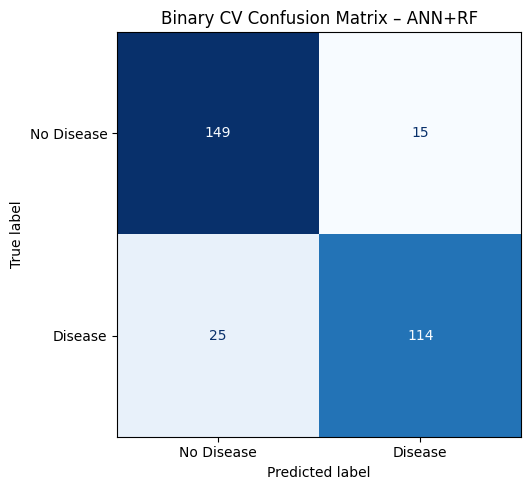

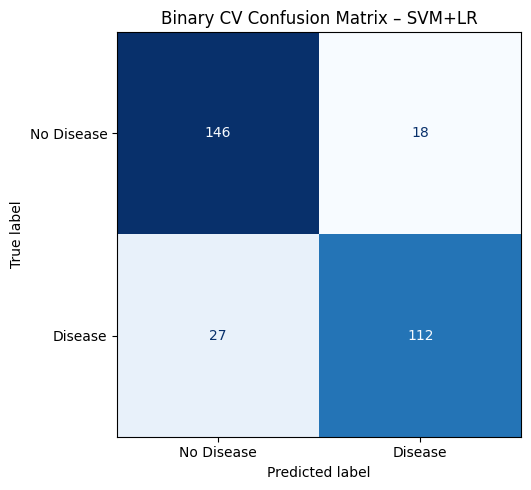

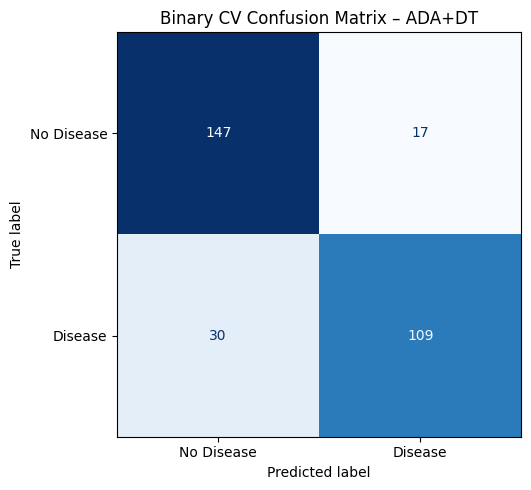

  ⚠ No valid ROC data for: Binary ROC Curve – ANN+RF
  ⚠ No valid ROC data for: Binary ROC Curve – SVM+LR


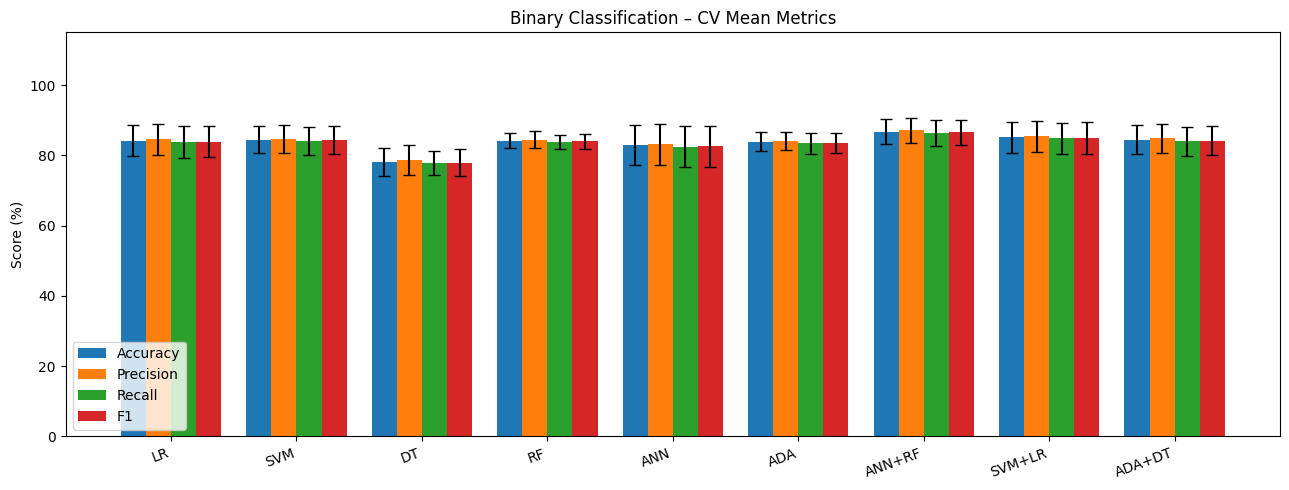


  ✓ Step 7 fully complete.


In [38]:
# ── STEP 7-E: BINARY CV – Summaries & Visualizations ─────────────────────

print("\n" + "="*65)
print("  BINARY CV SUMMARIES (Mean ± Std across 5 folds)")
print("="*65)

print("\n  Individual Models:")
for name, scores in binary_indiv_scores.items():
    print_cv_summary(name, scores)

print("\n  Fusion Models:")
for name, scores in binary_fusion_scores.items():
    print_cv_summary(name, scores)

# Confusion matrices
for key in ['ANN+RF', 'SVM+LR', 'ADA+DT']:
    plot_confusion_matrix(
        binary_agg[key]['y_true'],
        binary_agg[key]['y_pred'],
        labels=['No Disease', 'Disease'],
        title=f'Binary CV Confusion Matrix – {key}')

# ROC curves
for key in ['ANN+RF', 'SVM+LR']:
    if roc_fold_data[key]['fpr']:
        plot_roc_curve_binary(
            roc_fold_data[key]['fpr'],
            roc_fold_data[key]['tpr'],
            roc_fold_data[key]['auc'],
            title=f'Binary ROC Curve – {key}')

# Bar chart
all_binary_summary = {**binary_indiv_scores, **binary_fusion_scores}
plot_metric_bars(all_binary_summary,
                 'Binary Classification – CV Mean Metrics')

print("\n  ✓ Step 7 fully complete.")

# **STEP 8 – MULTI-CLASS CLASSIFICATION  (5-Fold CV)**


  MULTI-CLASS CLASSIFICATION – 5-Fold Stratified CV + GridSearch


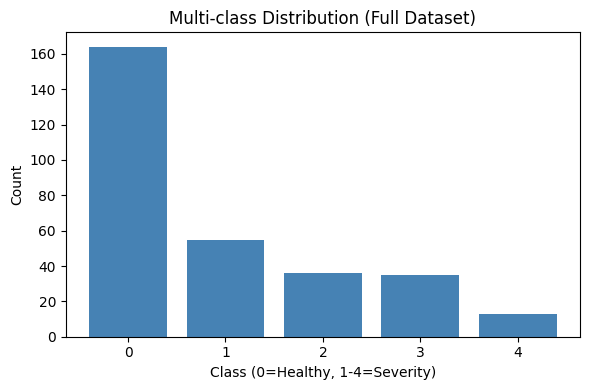


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train: 242 samples  |  Val: 61 samples
  After oversampling – train size: 655
  Class counts in train fold: {np.int64(0): np.int64(131), np.int64(1): np.int64(131), np.int64(2): np.int64(131), np.int64(3): np.int64(131), np.int64(4): np.int64(131)}

  Tuning multi-class models on fold 1...
    Fold 1 [LR                ] Acc=52.46%  Prec=59.01%  Recall=52.46%  F1=55.12%  ROC-AUC=80.25%
          Best params: {'C': 1, 'max_iter': 1000, 'multi_class': 'multinomial', 'solver': 'lbfgs'}
    Fold 1 [SVM               ] Acc=60.66%  Prec=57.67%  Recall=60.66%  F1=59.10%  ROC-AUC=75.28%
          Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
    Fold 1 [RF                ] Acc=62.30%  Prec=60.23%  Recall=62.30%  F1=61.24%  ROC-AUC=71.37%
          Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
    Fold 1 [ANN         

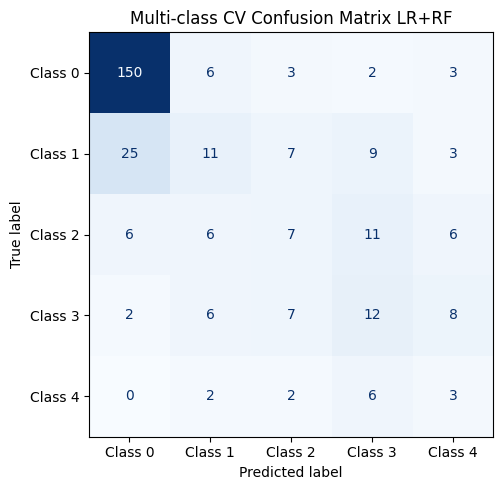

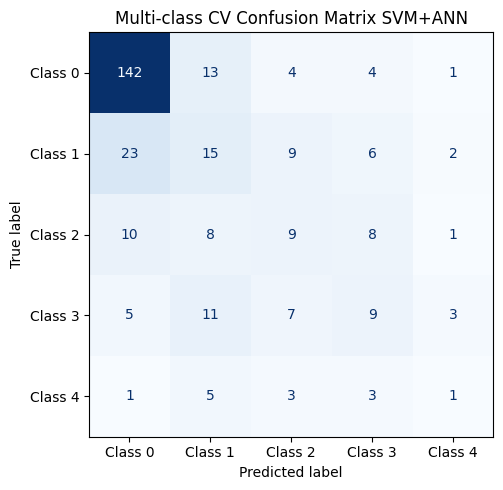

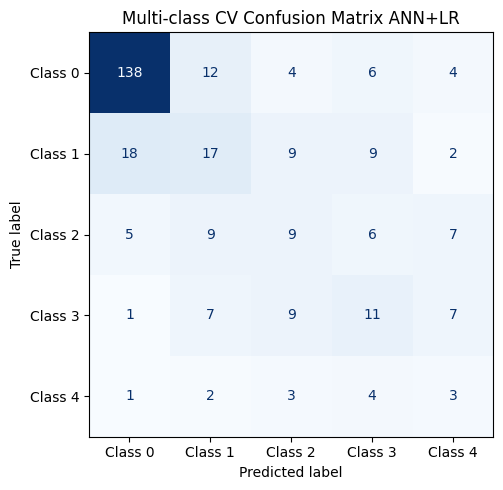

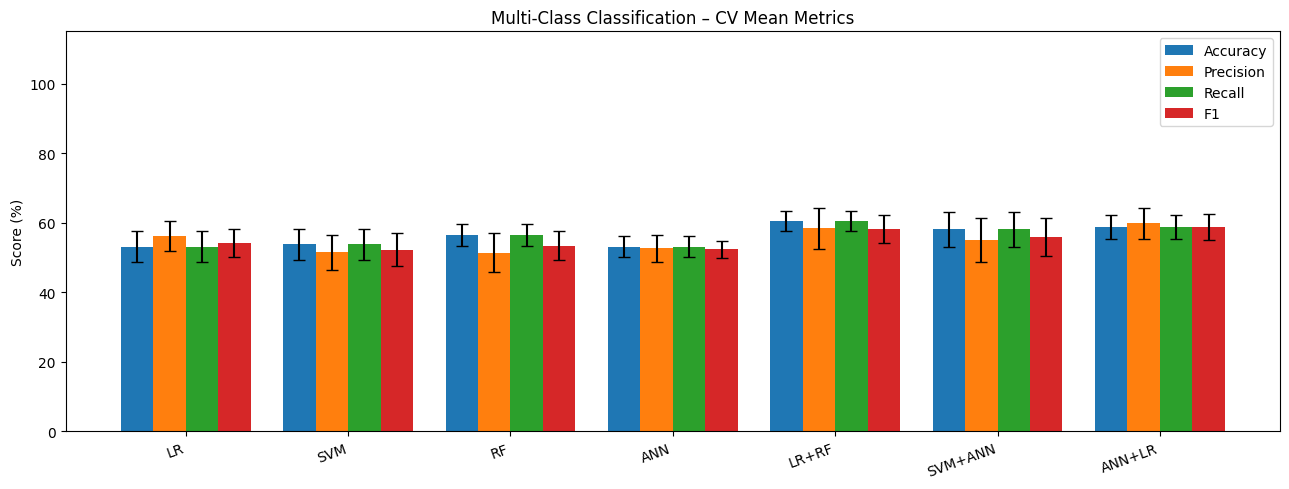


✅ All 5-Fold CV experiments complete!
   Saved: multiclass_distribution.png
          cm_*.png  |  roc_*.png  |  bar_*.png


In [33]:
print("\n" + "="*65)
print("  MULTI-CLASS CLASSIFICATION – 5-Fold Stratified CV + GridSearch")
print("="*65)

# Show class distribution BEFORE oversampling
plt.figure(figsize=(6, 4))
unique, counts = np.unique(y_multi, return_counts=True)
plt.bar([str(u) for u in unique], counts, color='steelblue')
plt.title('Multi-class Distribution (Full Dataset)')
plt.xlabel('Class (0=Healthy, 1-4=Severity)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('multiclass_distribution.png', dpi=120)
plt.show()

# ── Containers ────────────────────────────────────────────
multi_indiv_scores = {
    name: {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]}
    for name in BASE_MODELS_MULTI
}

multi_fusion_scores = {
    'LR+RF':   {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'SVM+ANN': {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'ANN+LR':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
}

multi_agg = {key: {'y_true':[], 'y_pred':[]}
             for key in list(BASE_MODELS_MULTI.keys()) +
                        list(multi_fusion_scores.keys())}

# ── Outer CV loop ─────────────────────────────────────────
outer_skf_multi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(
        outer_skf_multi.split(X, y_multi), 1):

    print(f"\n  {'━'*58}")
    print(f"  FOLD {fold_idx} / 5")
    print(f"  {'━'*58}")
    print(f"  Train: {len(train_idx)} samples  |  Val: {len(val_idx)} samples")

    X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
    y_tr,     y_val     = y_multi[train_idx], y_multi[val_idx]

    # ── RandomOverSampler – ONLY on training fold ─────────
    # Duplicates minority-class samples until all classes are equal.
    # NEVER applied to the validation fold (would cause leakage).
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr_raw, y_tr)

    print(f"  After oversampling – train size: {len(X_tr_res)}")
    unique_res, counts_res = np.unique(y_tr_res, return_counts=True)
    print(f"  Class counts in train fold: {dict(zip(unique_res, counts_res))}")

    # ── Scale AFTER oversampling, BEFORE training ─────────
    # Scaler fitted on oversampled training data; val fold untouched
    X_tr_std, X_val_std = scale_fold(X_tr_res, X_val_raw, 'standard')
    X_tr_mm,  X_val_mm  = scale_fold(X_tr_res, X_val_raw, 'minmax')

    scale_map_m = {
        'LR':  (X_tr_std, X_val_std),
        'SVM': (X_tr_std, X_val_std),
        'RF':  (X_tr_mm,  X_val_mm),
        'ANN': (X_tr_std, X_val_std),
    }

    # ── Tune & train each individual model ───────────────
    trained_m = {}
    print(f"\n  Tuning multi-class models on fold {fold_idx}...")

    for name, base in BASE_MODELS_MULTI.items():
        Xtr_, Xval_ = scale_map_m[name]

        # Inner GridSearch on oversampled training fold only
        best_model, best_params = tune_on_fold(
            name, base, PARAM_GRIDS_MULTI[name], Xtr_, y_tr_res)

        trained_m[name] = (best_model, Xval_)

        y_pred = best_model.predict(Xval_)
        y_prob = best_model.predict_proba(Xval_)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=True)

        multi_indiv_scores[name]['acc'].append(acc)
        multi_indiv_scores[name]['prc'].append(prc)
        multi_indiv_scores[name]['rec'].append(rec)
        multi_indiv_scores[name]['f1'].append(f1)
        multi_indiv_scores[name]['roc'].append(roc)

        multi_agg[name]['y_true'].extend(y_val)
        multi_agg[name]['y_pred'].extend(y_pred)

        print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
        print(f"          Best params: {best_params}")

    # ── Fusion Model-1: LR + RF ───────────────────────────
    print(f"\n  Multi-class fusion results for fold {fold_idx}:")
    lr_m,  _ = trained_m['LR']
    rf_m,  _ = trained_m['RF']
    y_pred_f1, prob_f1, w1 = weighted_score_fusion(
        lr_m, rf_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f1, prob_f1, multi=True)
    multi_fusion_scores['LR+RF']['acc'].append(acc)
    multi_fusion_scores['LR+RF']['prc'].append(prc)
    multi_fusion_scores['LR+RF']['rec'].append(rec)
    multi_fusion_scores['LR+RF']['f1'].append(f1)
    multi_fusion_scores['LR+RF']['roc'].append(roc)
    multi_agg['LR+RF']['y_true'].extend(y_val)
    multi_agg['LR+RF']['y_pred'].extend(y_pred_f1)
    print_fold_result(fold_idx, f"LR+RF (w1={w1})", acc, prc, rec, f1, roc)

    # ── Fusion Model-2: SVM + ANN ─────────────────────────
    svm_m, _ = trained_m['SVM']
    ann_m, _ = trained_m['ANN']
    y_pred_f2, prob_f2, w2 = weighted_score_fusion(
        svm_m, ann_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f2, prob_f2, multi=True)
    multi_fusion_scores['SVM+ANN']['acc'].append(acc)
    multi_fusion_scores['SVM+ANN']['prc'].append(prc)
    multi_fusion_scores['SVM+ANN']['rec'].append(rec)
    multi_fusion_scores['SVM+ANN']['f1'].append(f1)
    multi_fusion_scores['SVM+ANN']['roc'].append(roc)
    multi_agg['SVM+ANN']['y_true'].extend(y_val)
    multi_agg['SVM+ANN']['y_pred'].extend(y_pred_f2)
    print_fold_result(fold_idx, f"SVM+ANN (w1={w2})", acc, prc, rec, f1, roc)

    # ── Fusion Model-3: ANN + LR ──────────────────────────
    y_pred_f3, prob_f3, w3 = weighted_score_fusion(
        ann_m, lr_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f3, prob_f3, multi=True)
    multi_fusion_scores['ANN+LR']['acc'].append(acc)
    multi_fusion_scores['ANN+LR']['prc'].append(prc)
    multi_fusion_scores['ANN+LR']['rec'].append(rec)
    multi_fusion_scores['ANN+LR']['f1'].append(f1)
    multi_fusion_scores['ANN+LR']['roc'].append(roc)
    multi_agg['ANN+LR']['y_true'].extend(y_val)
    multi_agg['ANN+LR']['y_pred'].extend(y_pred_f3)
    print_fold_result(fold_idx, f"ANN+LR (w1={w3})", acc, prc, rec, f1, roc)

# ── Cross-validation Summaries ────────────────────────────
print("\n" + "="*65)
print("  MULTI-CLASS CV SUMMARIES (Mean ± Std across 5 folds)")
print("="*65)

print("\n  Individual Models:")
for name, scores in multi_indiv_scores.items():
    print_cv_summary(name, scores)

print("\n  Fusion Models:")
for name, scores in multi_fusion_scores.items():
    print_cv_summary(name, scores)

# ── Confusion matrices (aggregated across all folds) ──────
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
for key in ['LR+RF', 'SVM+ANN', 'ANN+LR']:
    plot_confusion_matrix(
        multi_agg[key]['y_true'],
        multi_agg[key]['y_pred'],
        labels=class_labels,
        title=f'Multi-class CV Confusion Matrix {key}')

# ── Bar chart comparing all multi-class models ────────────
all_multi_summary = {**multi_indiv_scores, **multi_fusion_scores}
plot_metric_bars(all_multi_summary,
                 'Multi-Class Classification – CV Mean Metrics')


# ╔══════════════════════════════════════════════════════════╗
# ║  DONE                                                   ║
# ╚══════════════════════════════════════════════════════════╝
print("\n✅ All 5-Fold CV experiments complete!")
print("   Saved: multiclass_distribution.png")
print("          cm_*.png  |  roc_*.png  |  bar_*.png")